In [580]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [581]:
def f(x):
    return 3*x**2 -4*x + 5

In [582]:
f(3.0)

20.0

In [583]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [584]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

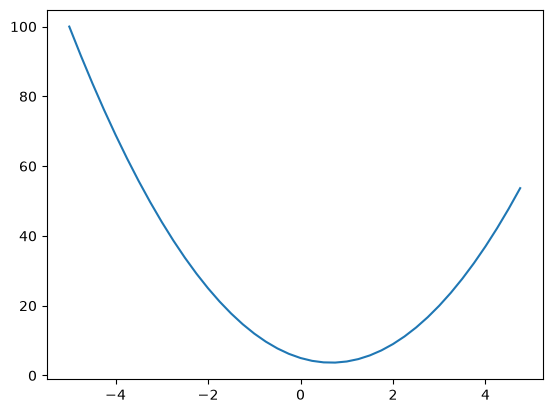

In [585]:
plt.plot(xs,ys)

In [586]:
h = 0.000001
x = -3.0
(f(x + h) - f(x))/h

-21.999997002808414

In [587]:
a = 2.0
b = -3.0
c = 10.0
d = a + b + c
d

9.0

In [588]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h
d2 = a * b + c

print('d1: ', d1)
print('d2: ', d2)
print('pendiente: ', (d2 - d1)/h)

d1:  4.0
d2:  4.0001
pendiente:  0.9999999999976694


In [589]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data = {self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'Solo acepta enteros y/o flotantes'
        out = Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, ((self, other)), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
            
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0 
        for node in reversed(topo):
            node._backward()

In [590]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

In [591]:
d._prev

{Value(data = -6.0), Value(data = 10.0)}

In [592]:
d._op

'+'

In [593]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label='{%s | data %.4f | grad %.4f}' % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
            
    return dot

## Backprop manual, obtencion de los gradientes

Grafo: `e = a*b`, `d = c+e`, `L = f*d`

Partimos de `L.grad = 1.0` y vamos hacia atrás aplicando regla de la cadena:
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial (\text{nodo hijo})} \times \frac{\partial (\text{nodo hijo})}{\partial x}$$

- **Multiplicación** (`L=f*d`): la derivada local de cada operando es el *otro* operando.
  → `f.grad = d = 4.0`, `d.grad = f = -2.0`

- **Suma** (`d=c+e`): la derivada local es siempre 1, así que el gradiente simplemente
  se copia sin cambios a ambos operandos ("router").
  → `c.grad = d.grad * 1 = -2.0`, `e.grad = d.grad * 1 = -2.0`

- **Multiplicación otra vez** (`e=a*b`): mismo patrón que arriba.
  → `a.grad = e.grad * b = 6.0`, `b.grad = e.grad * a = -4.0`

En resumen: en cada paso hacia atrás, tomamos el gradiente que ya traíamos y lo
multiplicamos por la derivada local de la operación — exactamente la regla de la
cadena aplicada nodo por nodo.

In [594]:
a.grad = 6.0
b.grad = -4.0
c.grad = -2.0
e.grad = -2.0
d.grad = -2.0
f.grad = 4.0
L.grad = 1.0

En backpropagation un signo de suma da a entender que el gradiente que tiene el nodo padre, sera pasado de la misma manera a los nodos hijos. \
Con un signo de multiplicación, la DERIVADA LOCAL es el valor del otro
componente. El gradiente final = derivada local × gradiente que viene del nodo padre.
Ejemplo: a*b=c. Derivada local de a es b. Si c.grad=2, entonces a.grad = b * 2.

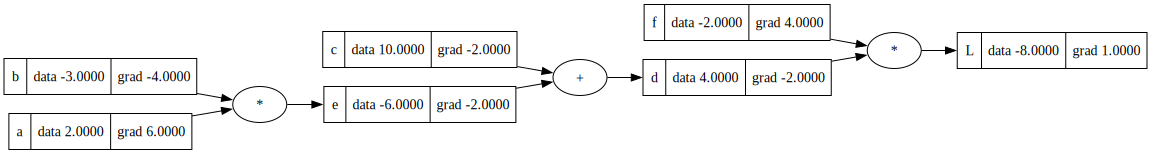

In [595]:
draw_dot(L)

In [596]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


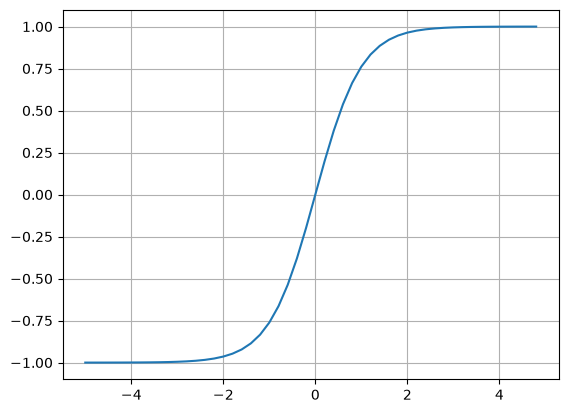

In [597]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid(); 

In [598]:
# Entradas
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Pesos
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# sesgo/bias
b = Value(6.881373587019543, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [599]:
o.grad = 1.0
n.grad = 0.5 # 1 - tanh(x)**2 / o = tanh
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

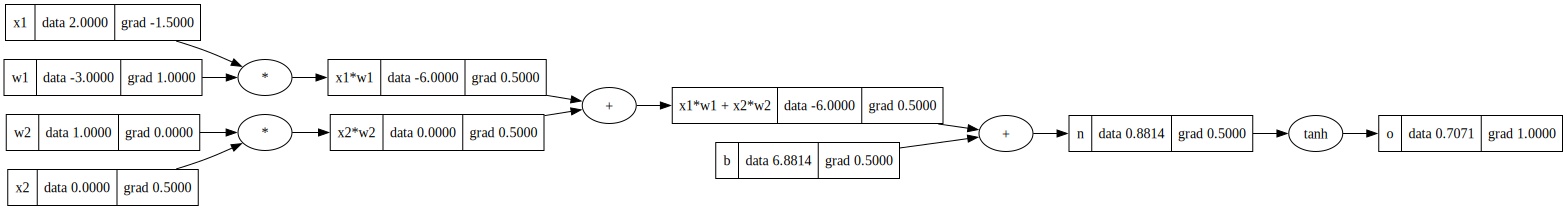

In [600]:
draw_dot(o)

# Backprpagation automatico con grafos topograficos

In [601]:
# Entradas
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Pesos
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# sesgo/bias
b = Value(6.881373587019543, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

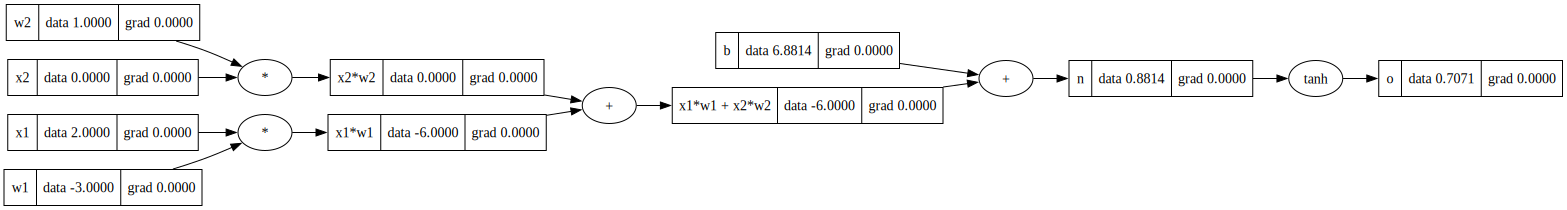

In [602]:
draw_dot(o)

In [603]:
o.backward()

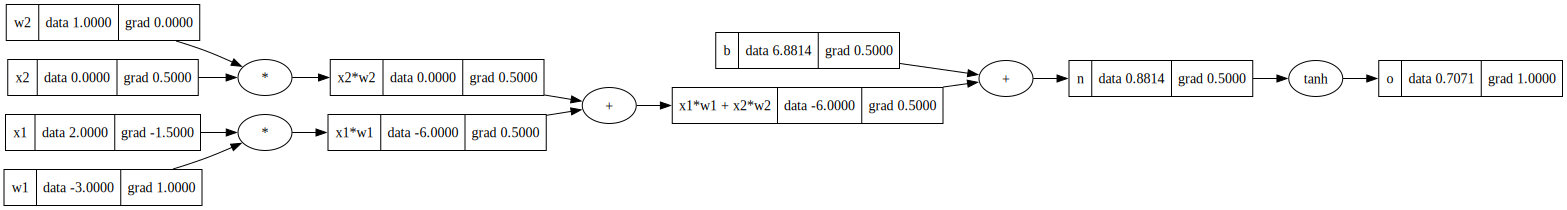

In [604]:
draw_dot(o)

# Desmenuzando Tanh

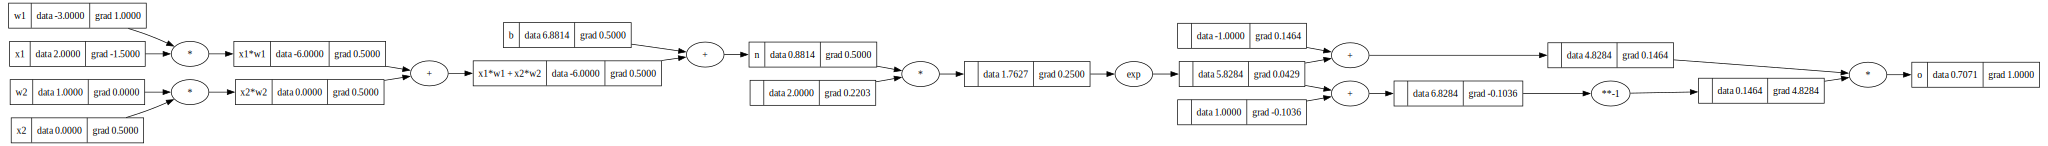

In [605]:
# Entradas
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Pesos
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# sesgo/bias
b = Value(6.881373587019543, label='b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e - 1)/(e + 1); o.label = 'o'
o.backward()
draw_dot(o)

In [606]:
import torch

x1 = torch.Tensor([2.0]).double()              ; x1.requires_grad_(True)
x2 = torch.Tensor([0.0]).double()              ; x2.requires_grad_(True)
w1 = torch.Tensor([-3.0]).double()             ; w1.requires_grad_(True)
w2 = torch.Tensor([1.0]).double()              ; w2.requires_grad_(True)
b = torch.Tensor([6.881373587019543]).double() ; b.requires_grad_(True) 
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.item())
o.backward()

print('--------------------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
--------------------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


# Red neuronal

In [607]:
np.random.seed(42)

class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1., 1.)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1., 1.)) 
        
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
mlp = MLP(3, [4, 4, 1])
mlp(x)

Value(data = -0.6490834594731474)

In [608]:
mlp.parameters()

[Value(data = -0.250919762305275),
 Value(data = 0.9014286128198323),
 Value(data = 0.4639878836228102),
 Value(data = 0.1973169683940732),
 Value(data = -0.687962719115127),
 Value(data = -0.6880109593275947),
 Value(data = -0.8838327756636011),
 Value(data = 0.7323522915498704),
 Value(data = 0.2022300234864176),
 Value(data = 0.416145155592091),
 Value(data = -0.9588310114083951),
 Value(data = 0.9398197043239886),
 Value(data = 0.6648852816008435),
 Value(data = -0.5753217786434477),
 Value(data = -0.6363500655857988),
 Value(data = -0.6331909802931324),
 Value(data = -0.39151551408092455),
 Value(data = 0.04951286326447568),
 Value(data = -0.13610996271576847),
 Value(data = -0.4175417196039162),
 Value(data = 0.22370578944475894),
 Value(data = -0.7210122786959163),
 Value(data = -0.4157107029295637),
 Value(data = -0.2672763134126166),
 Value(data = -0.08786003156592814),
 Value(data = 0.5703519227860272),
 Value(data = -0.6006524356832805),
 Value(data = 0.02846887682722321),
 

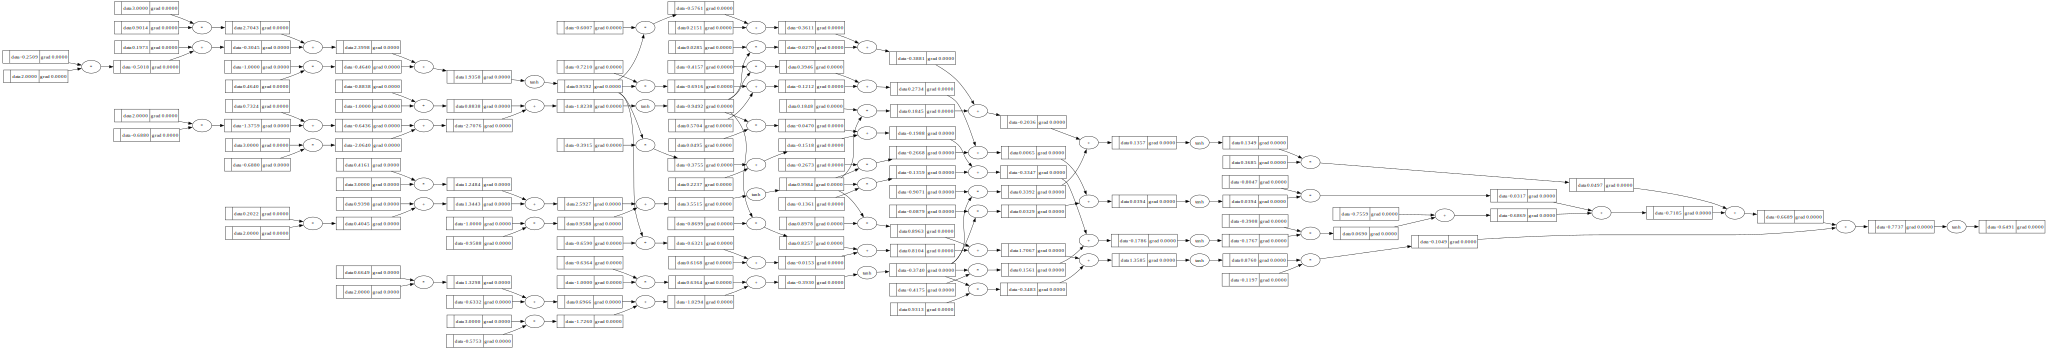

In [609]:
draw_dot(mlp(x))

In [ ]:
xs = [[2.0, 3.0, -1.0],
      [3.0, -1.0, 0.5],
      [0.5, 1.0, 1.0],
      [1.0, 1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0] # Valor esperado de salida para cada entrada


In [611]:
for k in range(40):
    # foward pass
    ypred = [mlp(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # backward pass
    for p in mlp.parameters():
        p.grad = 0.0
    loss.backward()
    #update
    for p in mlp.parameters():
        p.data += -0.08 * p.grad
    
    print(k, loss.data)

0 5.466021962407364
1 2.0082603663352594
2 1.3412110541001359
3 0.6937697140069762
4 0.353048495942742
5 0.16176438895405
6 0.12174685940533553
7 0.09707207282427716
8 0.08042639759074324
9 0.0684887402636043
10 0.0595344224194495
11 0.05258326415235056
12 0.04703896771588992
13 0.04251885972633711
14 0.038766545530492504
15 0.03560403230852094
16 0.03290402592789066
17 0.0305731605116306
18 0.028541450443921902
19 0.02675543473919645
20 0.025173592574495945
21 0.023763200182001953
22 0.022498127957512448
23 0.021357265987359285
24 0.02032337880934767
25 0.019382259122871892
26 0.01852209340072469
27 0.017732980115615193
28 0.01700655949084122
29 0.016335725838827007
30 0.01571440181069533
31 0.015137359582208073
32 0.014600077995802818
33 0.014098627514443235
34 0.013629576881800306
35 0.01318991686606724
36 0.012776997554827182
37 0.012388476477956304
38 0.012022275442466736
39 0.011676544422245895


In [612]:
ypred

[Value(data = 0.9388640025497029),
 Value(data = -0.9467837515622314),
 Value(data = -0.9467846244576845),
 Value(data = 0.9523021075297536)]